In [1]:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "Combined_News_DJIA.csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "aaron7sun/stocknews",
  file_path
)
df.head()


/tmp/ipykernel_14724/747287389.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'stocknews' dataset.


,Date,Label,Top1,Top2,Top3,Top4,Top5,Top6,Top7,Top8,...,Top16,Top17,Top18,Top19,Top20,Top21,Top22,Top23,Top24,Top25
0,2008-08-08,0,"b""Georgia 'downs two Russian warplanes' as cou...",b'BREAKING: Musharraf to be impeached.',b'Russia Today: Columns of troops roll into So...,b'Russian tanks are moving towards the capital...,"b""Afghan children raped with 'impunity,' U.N. ...",b'150 Russian tanks have entered South Ossetia...,"b""Breaking: Georgia invades South Ossetia, Rus...","b""The 'enemy combatent' trials are nothing but...",...,b'Georgia Invades South Ossetia - if Russia ge...,b'Al-Qaeda Faces Islamist Backlash',"b'Condoleezza Rice: ""The US would not act to p...",b'This is a busy day: The European Union has ...,"b""Georgia will withdraw 1,000 soldiers from Ir...",b'Why the Pentagon Thinks Attacking Iran is a ...,b'Caucasus in crisis: Georgia invades South Os...,b'Indian shoe manufactory - And again in a se...,b'Visitors Suffering from Mental Illnesses Ban...,"b""No Help for Mexico's Kidnapping Surge"""
1,2008-08-11,1,b'Why wont America and Nato help us? If they w...,b'Bush puts foot down on Georgian conflict',"b""Jewish Georgian minister: Thanks to Israeli ...",b'Georgian army flees in disarray as Russians ...,"b""Olympic opening ceremony fireworks 'faked'""",b'What were the Mossad with fraudulent New Zea...,b'Russia angered by Israeli military sale to G...,b'An American citizen living in S.Ossetia blam...,...,b'Israel and the US behind the Georgian aggres...,"b'""Do not believe TV, neither Russian nor Geor...",b'Riots are still going on in Montreal (Canada...,b'China to overtake US as largest manufacturer',b'War in South Ossetia [PICS]',b'Israeli Physicians Group Condemns State Tort...,b' Russia has just beaten the United States ov...,b'Perhaps *the* question about the Georgia - R...,b'Russia is so much better at war',"b""So this is what it's come to: trading sex fo..."
2,2008-08-12,0,b'Remember that adorable 9-year-old who sang a...,"b""Russia 'ends Georgia operation'""","b'""If we had no sexual harassment we would hav...","b""Al-Qa'eda is losing support in Iraq because ...",b'Ceasefire in Georgia: Putin Outmaneuvers the...,b'Why Microsoft and Intel tried to kill the XO...,b'Stratfor: The Russo-Georgian War and the Bal...,"b""I'm Trying to Get a Sense of This Whole Geor...",...,b'U.S. troops still in Georgia (did you know t...,b'Why Russias response to Georgia was right',"b'Gorbachev accuses U.S. of making a ""serious ...","b'Russia, Georgia, and NATO: Cold War Two'",b'Remember that adorable 62-year-old who led y...,b'War in Georgia: The Israeli connection',b'All signs point to the US encouraging Georgi...,b'Christopher King argues that the US and NATO...,b'America: The New Mexico?',"b""BBC NEWS | Asia-Pacific | Extinction 'by man..."
3,2008-08-13,0,b' U.S. refuses Israel weapons to attack Iran:...,"b""When the president ordered to attack Tskhinv...",b' Israel clears troops who killed Reuters cam...,b'Britain\'s policy of being tough on drugs is...,b'Body of 14 year old found in trunk; Latest (...,b'China has moved 10 *million* quake survivors...,"b""Bush announces Operation Get All Up In Russi...",b'Russian forces sink Georgian ships ',...,b'Elephants extinct by 2020?',b'US humanitarian missions soon in Georgia - i...,"b""Georgia's DDOS came from US sources""","b'Russian convoy heads into Georgia, violating...",b'Israeli defence minister: US against strike ...,b'Gorbachev: We Had No Choice',b'Witness: Russian forces head towards Tbilisi...,b' Quarter of Russians blame U.S. for conflict...,b'Georgian president says US military will ta...,b'2006: Nobel laureate Aleksander Solzhenitsyn...
4,2008-08-14,1,b'All the experts admit that we should legalis...,b'War in South Osetia - 89 pictures made by a ...,b'Swedish wrestler Ara Abrahamian throws away ...,b'Russia exaggerated the death toll in South O...,b'Missile That Killed 9 Inside Pakistan May Ha...,"b""Rushdie Condemns Random House's Refusal to P...",b'Poland and US agree 

# Project 4 — News-Based Stock Market Prediction (NLP + Finance)

**Dataset:** Daily News for Stock Market Prediction (Kaggle)  
**Goal:** Predict daily DJIA direction (Up=1 / Down=0) from news headlines.

**Pipeline:**
1. Load & explore data
2. Preprocess headlines
3. **Feature extraction ×2:**
   - Word2Vec embeddings (average pooling) — tokens without stemming for better semantics
   - TF-IDF (unigram + bigram) — stemmed tokens for compact vocabulary
4. Classifiers: Logistic Regression, Random Forest, Linear SVM
5. Baseline naïve (majority class)
6. Backtest avec signal décalé d'un jour (pas de look-ahead)

> **Dataset link:** https://www.kaggle.com/datasets/aaron7sun/stocknews  
> Files needed: `Combined_News_DJIA.csv` and `upload_DJIA_table.csv`


## 1. Install & Import

In [2]:
!pip install gensim scikit-learn tqdm nltk


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 27.0 MB/s eta 0:00:00


In [3]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, matthews_corrcoef, classification_report,
    ConfusionMatrixDisplay, average_precision_score, brier_score_loss
)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

RANDOM_STATE = 42
sns.set_theme(style='whitegrid')
print('Classical NLP pipeline only (CPU-friendly).')


Classical NLP pipeline only (CPU-friendly).


## 2. Load Data

In [4]:
dataset_path = kagglehub.dataset_download("aaron7sun/stocknews")

news_file = os.path.join(dataset_path, "Combined_News_DJIA.csv")
price_file = os.path.join(dataset_path, "upload_DJIA_table.csv")

df_news = pd.read_csv(news_file)
df_price = pd.read_csv(price_file)

df_news["Date"] = pd.to_datetime(df_news["Date"])
df_price["Date"] = pd.to_datetime(df_price["Date"])

print('News shape :', df_news.shape)
print('Price shape:', df_price.shape)

display(df_news.head(3))
display(df_price.head(3))


Using Colab cache for faster access to the 'stocknews' dataset.
News shape : (1989, 27)
Price shape: (1989, 7)


,Date,Label,Top1,Top2,Top3,Top4,Top5,Top6,Top7,Top8,...,Top16,Top17,Top18,Top19,Top20,Top21,Top22,Top23,Top24,Top25
0,2008-08-08,0,"b""Georgia 'downs two Russian warplanes' as cou...",b'BREAKING: Musharraf to be impeached.',b'Russia Today: Columns of troops roll into So...,b'Russian tanks are moving towards the capital...,"b""Afghan children raped with 'impunity,' U.N. ...",b'150 Russian tanks have entered South Ossetia...,"b""Breaking: Georgia invades South Ossetia, Rus...","b""The 'enemy combatent' trials are nothing but...",...,b'Georgia Invades South Ossetia - if Russia ge...,b'Al-Qaeda Faces Islamist Backlash',"b'Condoleezza Rice: ""The US would not act to p...",b'This is a busy day: The European Union has ...,"b""Georgia will withdraw 1,000 soldiers from Ir...",b'Why the Pentagon Thinks Attacking Iran is a ...,b'Caucasus in crisis: Georgia invades South Os...,b'Indian shoe manufactory - And again in a se...,b'Visitors Suffering from Mental Illnesses Ban...,"b""No Help for Mexico's Kidnapping Surge"""
1,2008-08-11,1,b'Why wont America and Nato help us? If they w...,b'Bush puts foot down on Georgian conflict',"b""Jewish Georgian minister: Thanks to Israeli ...",b'Georgian army flees in disarray as Russians ...,"b""Olympic opening ceremony fireworks 'faked'""",b'What were the Mossad with fraudulent New Zea...,b'Russia angered by Israeli military sale to G...,b'An American citizen living in S.Ossetia blam...,...,b'Israel and the US behind the Georgian aggres...,"b'""Do not believe TV, neither Russian nor Geor...",b'Riots are still going on in Montreal (Canada...,b'China to overtake US as largest manufacturer',b'War in South Ossetia [PICS]',b'Israeli Physicians Group Condemns State Tort...,b' Russia has just beaten the United States ov...,b'Perhaps *the* question about the Georgia - R...,b'Russia is so much better at war',"b""So this is what it's come to: trading sex fo..."
2,2008-08-12,0,b'Remember that adorable 9-year-old who sang a...,"b""Russia 'ends Georgia operation'""","b'""If we had no sexual harassment we would hav...","b""Al-Qa'eda is losing support in Iraq because ...",b'Ceasefire in Georgia: Putin Outmaneuvers the...,b'Why Microsoft and Intel tried to kill the XO...,b'Stratfor: The Russo-Georgian War and the Bal...,"b""I'm Trying to Get a Sense of This Whole Geor...",...,b'U.S. troops still in Georgia (did you know t...,b'Why Russias response to Georgia was right',"b'Gorbachev accuses U.S. of making a ""serious ...","b'Russia, Georgia, and NATO: Cold War Two'",b'Remember that adorable 62-year-old who led y...,b'War in Georgia: The Israeli connection',b'All signs point to the US encouraging Georgi...,b'Christopher King argues that the US and NATO...,b'America: The New Mexico?',"b""BBC NEWS | Asia-Pacific | Extinction 'by man..."


,Date,Open,High,Low,Close,Volume,Adj Close
0,2016-07-01,17924.240234,18002.380859,17916.910156,17949.369141,82160000,17949.369141
1,2016-06-30,17712.759766,17930.609375,17711.800781,17929.990234,133030000,17929.990234
2,2016-06-29,17456.019531,17704.509766,17456.019531,17694.679688,106380000,17694.679688


In [5]:
# DATA VALIDATION & EDA

print("===== INITIAL DATA CHECK =====")
print("News shape :", df_news.shape)
print("Price shape:", df_price.shape)
print()

print("News columns:")
print(df_news.columns.tolist())
print()

print("Price columns:")
print(df_price.columns.tolist())
print()

display(df_news.head(2))
display(df_price.head(2))


# 1. Types de données

print("===== DTYPES BEFORE CONVERSION =====")
print(df_news.dtypes)
print()
print(df_price.dtypes)

# Conversion des dates si nécessaire
df_news["Date"] = pd.to_datetime(df_news["Date"], errors="coerce")
df_price["Date"] = pd.to_datetime(df_price["Date"], errors="coerce")

# Conversion du label si nécessaire
if "Label" in df_news.columns:
    df_news["Label"] = pd.to_numeric(df_news["Label"], errors="coerce")

print("\n===== DTYPES AFTER CONVERSION =====")
print(df_news.dtypes)
print()
print(df_price.dtypes)


# 2. Valeurs manquantes

print("\n===== MISSING VALUES =====")
print("Missing values in df_news:")
print(df_news.isnull().sum().sort_values(ascending=False))
print()
print("Missing values in df_price:")
print(df_price.isnull().sum().sort_values(ascending=False))


# 3. Doublons

print("\n===== DUPLICATES =====")

# Colonnes sûres pour vérifier les doublons dans news
news_dup_cols = [col for col in df_news.columns if col in ["Date", "Label"] or str(col).startswith("Top")]
price_dup_cols = df_price.columns.tolist()

print("Columns used for duplicate check in df_news:", news_dup_cols)
print("Columns used for duplicate check in df_price:", price_dup_cols)

print("Duplicate rows in df_news:", df_news.duplicated(subset=news_dup_cols).sum())
print("Duplicate rows in df_price:", df_price.duplicated(subset=price_dup_cols).sum())

# 4. Vérification des dates

print("\n===== DATE RANGE =====")
print("df_news :", df_news["Date"].min(), "->", df_news["Date"].max())
print("df_price:", df_price["Date"].min(), "->", df_price["Date"].max())

print("\nUnique dates in df_news :", df_news["Date"].nunique())
print("Unique dates in df_price:", df_price["Date"].nunique())


# 5. Vérification des colonnes métier

print("\n===== BUSINESS COLUMNS CHECK =====")
required_news_cols = ["Date", "Label"]
required_price_cols = ["Date"]

missing_news_cols = [c for c in required_news_cols if c not in df_news.columns]
missing_price_cols = [c for c in required_price_cols if c not in df_price.columns]

print("Missing required columns in df_news:", missing_news_cols)
print("Missing required columns in df_price:", missing_price_cols)

top_cols = [col for col in df_news.columns if col.startswith("Top")]
print("Number of Top columns found:", len(top_cols))
print("Top columns:", top_cols[:10], "..." if len(top_cols) > 10 else "")


# 6. Distribution du label

if "Label" in df_news.columns:
    print("\n===== LABEL DISTRIBUTION =====")
    print(df_news["Label"].value_counts(dropna=False))
    print()
    print(df_news["Label"].value_counts(normalize=True, dropna=False))


# 7. Vérification de la jointure sur Date

merged_check = pd.merge(df_news, df_price, on="Date", how="inner")

print("\n===== MERGE CHECK =====")
print("Rows in df_news   :", len(df_news))
print("Rows in df_price  :", len(df_price))
print("Rows after merge  :", len(merged_check))
print("Rows lost from news after merge:", len(df_news) - len(merged_check))



# 8. Vérification cohérence métier du label

# On essaie de vérifier si Label = 1 correspond à une hausse du marché
price_cols_lower = {c.lower(): c for c in df_price.columns}

if "open" in price_cols_lower and "close" in price_cols_lower and "Label" in df_news.columns:
    open_col = price_cols_lower["open"]
    close_col = price_cols_lower["close"]

    temp_price = df_price[["Date", open_col, close_col]].copy()
    temp_price["market_up"] = (temp_price[close_col] > temp_price[open_col]).astype(int)

    label_check = pd.merge(
        df_news[["Date", "Label"]],
        temp_price[["Date", "market_up"]],
        on="Date",
        how="inner"
    )

    consistency = (label_check["Label"] == label_check["market_up"]).mean()

    print("\n===== LABEL / MARKET CONSISTENCY =====")
    print("Consistency ratio:", round(consistency, 4))
    print("Interpretation: close > open should usually match Label = 1")
else:
    print("\n===== LABEL / MARKET CONSISTENCY =====")
    print("Open/Close columns not found automatically in df_price.")


# 9. Vérification rapide du texte

if len(top_cols) > 0:
    text_nulls = df_news[top_cols].isnull().sum().sum()
    print("\n===== TEXT QUALITY CHECK =====")
    print("Total missing values across Top columns:", text_nulls)

    sample_text = " ".join(
        str(df_news[top_cols].iloc[0][col]) for col in top_cols if pd.notnull(df_news[top_cols].iloc[0][col])
    )
    print("Sample combined text:")
    print(sample_text[:500])


print("\n===== END OF DATA VALIDATION =====")

===== INITIAL DATA CHECK =====
News shape : (1989, 27)
Price shape: (1989, 7)

News columns:
['Date', 'Label', 'Top1', 'Top2', 'Top3', 'Top4', 'Top5', 'Top6', 'Top7', 'Top8', 'Top9', 'Top10', 'Top11', 'Top12', 'Top13', 'Top14', 'Top15', 'Top16', 'Top17', 'Top18', 'Top19', 'Top20', 'Top21', 'Top22', 'Top23', 'Top24', 'Top25']

Price columns:
['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Adj Close']



,Date,Label,Top1,Top2,Top3,Top4,Top5,Top6,Top7,Top8,...,Top16,Top17,Top18,Top19,Top20,Top21,Top22,Top23,Top24,Top25
0,2008-08-08,0,"b""Georgia 'downs two Russian warplanes' as cou...",b'BREAKING: Musharraf to be impeached.',b'Russia Today: Columns of troops roll into So...,b'Russian tanks are moving towards the capital...,"b""Afghan children raped with 'impunity,' U.N. ...",b'150 Russian tanks have entered South Ossetia...,"b""Breaking: Georgia invades South Ossetia, Rus...","b""The 'enemy combatent' trials are nothing but...",...,b'Georgia Invades South Ossetia - if Russia ge...,b'Al-Qaeda Faces Islamist Backlash',"b'Condoleezza Rice: ""The US would not act to p...",b'This is a busy day: The European Union has ...,"b""Georgia will withdraw 1,000 soldiers from Ir...",b'Why the Pentagon Thinks Attacking Iran is a ...,b'Caucasus in crisis: Georgia invades South Os...,b'Indian shoe manufactory - And again in a se...,b'Visitors Suffering from Mental Illnesses Ban...,"b""No Help for Mexico's Kidnapping Surge"""
1,2008-08-11,1,b'Why wont America and Nato help us? If they w...,b'Bush puts foot down on Georgian conflict',"b""Jewish Georgian minister: Thanks to Israeli ...",b'Georgian army flees in disarray as Russians ...,"b""Olympic opening ceremony fireworks 'faked'""",b'What were the Mossad with fraudulent New Zea...,b'Russia angered by Israeli military sale to G...,b'An American citizen living in S.Ossetia blam...,...,b'Israel and the US behind the Georgian aggres...,"b'""Do not believe TV, neither Russian nor Geor...",b'Riots are still going on in Montreal (Canada...,b'China to overtake US as largest manufacturer',b'War in South Ossetia [PICS]',b'Israeli Physicians Group Condemns State Tort...,b' Russia has just beaten the United States ov...,b'Perhaps *the* question about the Georgia - R...,b'Russia is so much better at war',"b""So this is what it's come to: trading sex fo..."


,Date,Open,High,Low,Close,Volume,Adj Close
0,2016-07-01,17924.240234,18002.380859,17916.910156,17949.369141,82160000,17949.369141
1,2016-06-30,17712.759766,17930.609375,17711.800781,17929.990234,133030000,17929.990234


===== DTYPES BEFORE CONVERSION =====
Date     datetime64[ns]
Label             int64
Top1             object
Top2             object
Top3             object
Top4             object
Top5             object
Top6             object
Top7             object
Top8             object
Top9             object
Top10            object
Top11            object
Top12            object
Top13            object
Top14            object
Top15            object
Top16            object
Top17            object
Top18            object
Top19            object
Top20            object
Top21            object
Top22            object
Top23            object
Top24            object
Top25            object
dtype: object

Date         datetime64[ns]
Open                float64
High                float64
Low                 float64
Close               float64
Volume                int64
Adj Close           float64
dtype: object

===== DTYPES AFTER CONVERSION =====
Date     datetime64[ns]
Label             int64
Top1 

In [6]:
# LABEL VS MARKET CONSISTENCY CHECK

print("\n===== LABEL VS MARKET CONSISTENCY =====")

# Vérifie que les colonnes nécessaires existent
required_news_cols = ["Date", "Label"]
required_price_cols = ["Date", "Open", "Close"]

missing_news = [col for col in required_news_cols if col not in df_news.columns]
missing_price = [col for col in required_price_cols if col not in df_price.columns]

if missing_news:
    print("Missing columns in df_news:", missing_news)

if missing_price:
    print("Missing columns in df_price:", missing_price)

if not missing_news and not missing_price:
    # Copie locale pour ne pas modifier les dfs principaux
    news_check = df_news[["Date", "Label"]].copy()
    price_check = df_price[["Date", "Open", "Close"]].copy()

    # S'assurer que les types sont corrects
    news_check["Date"] = pd.to_datetime(news_check["Date"], errors="coerce")
    price_check["Date"] = pd.to_datetime(price_check["Date"], errors="coerce")

    news_check["Label"] = pd.to_numeric(news_check["Label"], errors="coerce")
    price_check["Open"] = pd.to_numeric(price_check["Open"], errors="coerce")
    price_check["Close"] = pd.to_numeric(price_check["Close"], errors="coerce")

    # Supprimer lignes invalides
    news_check = news_check.dropna(subset=["Date", "Label"]).copy()
    price_check = price_check.dropna(subset=["Date", "Open", "Close"]).copy()

    # Construire le signal marché
    price_check["market_up"] = (price_check["Close"] > price_check["Open"]).astype(int)
    price_check["market_return"] = price_check["Close"] - price_check["Open"]

    # Jointure sur la date
    label_market_check = pd.merge(
        news_check,
        price_check[["Date", "Open", "Close", "market_up", "market_return"]],
        on="Date",
        how="inner"
    )

    print("Rows compared:", len(label_market_check))

    if len(label_market_check) == 0:
        print("No matching rows found between df_news and df_price on Date.")
    else:
        # Taux de cohérence
        consistency_ratio = (label_market_check["Label"].astype(int) == label_market_check["market_up"]).mean()

        print("Consistency ratio:", round(consistency_ratio, 4))
        print("Interpretation: Label should usually match whether Close > Open")

        # Tableau de confusion simple
        confusion_table = pd.crosstab(
            label_market_check["Label"],
            label_market_check["market_up"],
            rownames=["Label"],
            colnames=["Market Up"]
        )

        print("\nConfusion table:")
        display(confusion_table)

        # Exemples incohérents
        mismatches = label_market_check[
            label_market_check["Label"].astype(int) != label_market_check["market_up"]
        ].copy()

        print("Number of mismatches:", len(mismatches))

        if len(mismatches) > 0:
            print("\nSample mismatches:")
            display(mismatches.head(10))

        # Résumé métier
        print("\nBusiness summary:")
        print("- market_up = 1 when Close > Open")
        print("- Label     = 1 should normally mean market went up")
        print("- If consistency is low, check label definition or date alignment")


===== LABEL VS MARKET CONSISTENCY =====
Rows compared: 1989
Consistency ratio: 0.9839
Interpretation: Label should usually match whether Close > Open

Confusion table:


Market Up,0,1
Label,,
0,902,22
1,10,1055


Number of mismatches: 32

Sample mismatches:


,Date,Label,Open,Close,market_up,market_return
0,2008-08-08,0,11432.089844,11734.320312,1,302.230468
129,2009-02-12,0,7931.970215,7932.759766,1,0.789551
323,2009-11-18,0,10426.269531,10426.309570,1,0.040039
430,2010-04-26,1,11205.110352,11205.030273,0,-0.080079
485,2010-07-14,1,10370.959961,10366.719727,0,-4.240234
497,2010-07-30,0,10465.190430,10465.940430,1,0.750000
561,2010-10-29,1,11120.450195,11118.490234,0,-1.959961
634,2011-02-14,0,12266.830078,12268.190430,1,1.360352
650,2011-03-09,0,12211.160156,12213.089844,1,1.929688
893,2012-02-24,0,12981.200195,12982.950195,1,1.750000



Business summary:
- market_up = 1 when Close > Open
- Label     = 1 should normally mean market went up
- If consistency is low, check label definition or date alignment


In [7]:
# LABEL DISTRIBUTION

print("\n===== LABEL DISTRIBUTION =====")

label_counts = df_news["Label"].value_counts()
label_ratio = df_news["Label"].value_counts(normalize=True)

print("Counts:")
print(label_counts)

print("\nProportions:")
print(label_ratio)


===== LABEL DISTRIBUTION =====
Counts:
Label
1    1065
0     924
Name: count, dtype: int64

Proportions:
Label
1    0.535445
0    0.464555
Name: proportion, dtype: float64


## 3. Exploratory Data Analysis

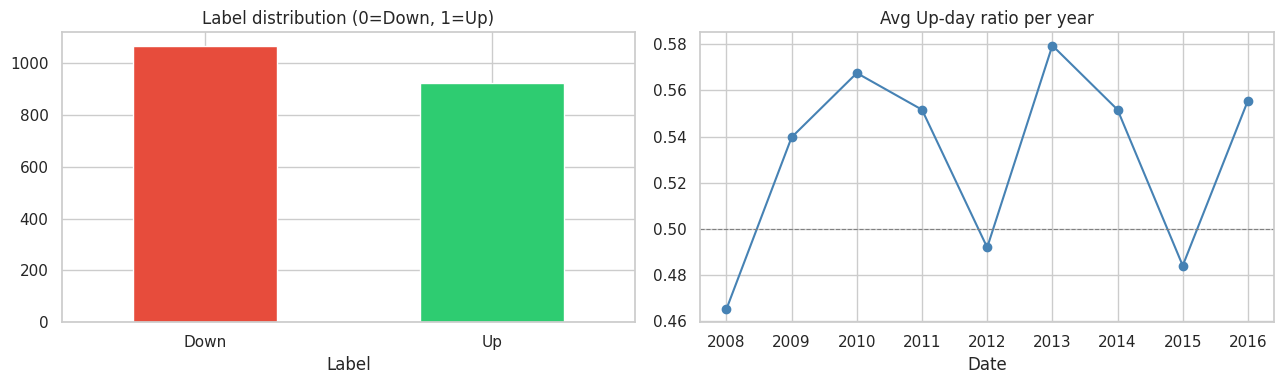

In [8]:
df_news['Date'] = pd.to_datetime(df_news['Date'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Label balance
df_news['Label'].value_counts().plot.bar(ax=axes[0], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Label distribution (0=Down, 1=Up)')
axes[0].set_xticklabels(['Down', 'Up'], rotation=0)

# Yearly ratio of up-days
yearly = df_news.set_index('Date').resample('YE')['Label'].mean()
yearly.index = yearly.index.year
yearly.plot(ax=axes[1], marker='o', color='steelblue')
axes[1].set_title('Avg Up-day ratio per year')
axes[1].axhline(0.5, ls='--', color='grey', lw=0.8)

plt.tight_layout()
plt.show()

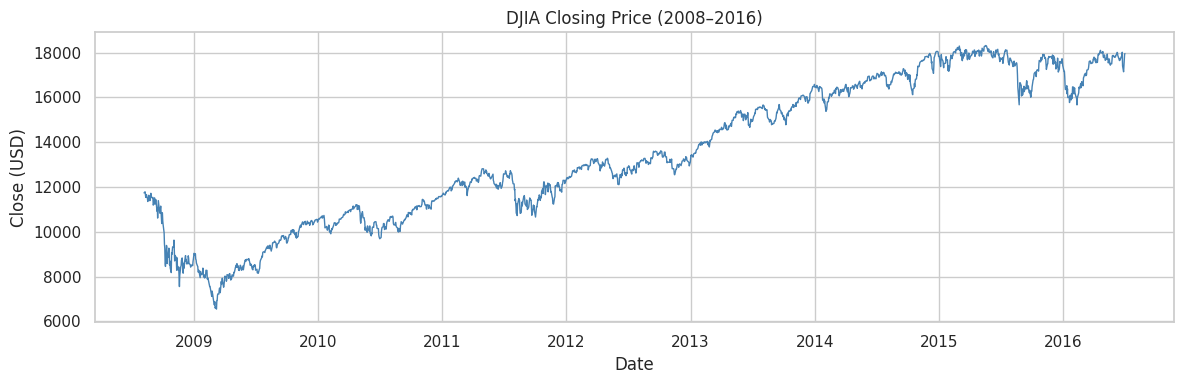

In [9]:
df_price_sorted = df_price.sort_values('Date')
plt.figure(figsize=(12, 4))
plt.plot(df_price_sorted['Date'], df_price_sorted['Close'], lw=1, color='steelblue')
plt.title('DJIA Closing Price (2008–2016)')
plt.xlabel('Date'); plt.ylabel('Close (USD)')
plt.tight_layout()
plt.show()

## 4. Text Preprocessing

For each day we concatenate the 25 headlines, then clean the text.

We maintain **two versions** of the corpus:

| Version | Stemming | Usage |
|---|---|---|
| `corpus_tokens` (raw) | ❌ No | Word2Vec — preserves semantic context |
| `corpus_tokens_stemmed` | ✅ Yes | TF-IDF — compact vocabulary |
| `corpus_str_raw` | ❌ No | Manual test cases (must match vectorizer input) |
| `corpus_str_stemmed` | ✅ Yes | TF-IDF vectorizer |

> **Why two versions?**  
> Word2Vec learns from *context* — stemming destroys contextual nuance ("economy" vs "economies" carry distinct co-occurrence signals).  
> TF-IDF benefits from stemming to reduce vocabulary size and merge morphological variants.

**NaN filling:** empty string `""` instead of column mode to avoid injecting a repeated headline.


In [10]:
STOP_WORDS = set(stopwords.words('english'))
stemmer    = PorterStemmer()
HEADLINE_COLS = [c for c in df_news.columns if c.startswith('Top')]

# FIX: fill NaN with empty string instead of column mode (mode injects a repeated headline)
for col in HEADLINE_COLS:
    df_news[col] = df_news[col].fillna('')

def clean_text(row):
    """Join headlines, remove non-alpha characters, lowercase."""
    text = ' '.join(str(v) for v in row)
    text = re.sub(r'[^a-zA-Z]', ' ', text).lower()
    return text

def tokenize_raw(row):
    """Tokens WITHOUT stemming — for Word2Vec."""
    text = clean_text(row)
    return [w for w in text.split() if w not in STOP_WORDS and len(w) > 1]

def tokenize_stemmed(row):
    """Tokens WITH stemming — for TF-IDF."""
    text = clean_text(row)
    return [stemmer.stem(w) for w in text.split() if w not in STOP_WORDS and len(w) > 1]

# Raw tokens (Word2Vec)
df_news['tokens_raw']    = df_news[HEADLINE_COLS].apply(tokenize_raw,    axis=1)
# Stemmed tokens (TF-IDF)
df_news['tokens_stemmed']= df_news[HEADLINE_COLS].apply(tokenize_stemmed, axis=1)
# String versions
df_news['corpus_raw']    = df_news['tokens_raw'].apply(lambda t: ' '.join(t))
df_news['corpus_stemmed']= df_news['tokens_stemmed'].apply(lambda t: ' '.join(t))

print('Raw tokens sample    :', df_news['tokens_raw'].iloc[0][:12])
print('Stemmed tokens sample:', df_news['tokens_stemmed'].iloc[0][:12])


Raw tokens sample    : ['georgia', 'downs', 'two', 'russian', 'warplanes', 'countries', 'move', 'brink', 'war', 'breaking', 'musharraf', 'impeached']
Stemmed tokens sample: ['georgia', 'down', 'two', 'russian', 'warplan', 'countri', 'move', 'brink', 'war', 'break', 'musharraf', 'impeach']


## 5. Temporal Train / Test Split

Train on data **before 2015**, test on **2015 and after** — no look-ahead bias.


In [11]:
# TEMPORAL TRAIN / TEST SPLIT + TARGET t+1

# Course logic:
# - respect time ordering
# - avoid leakage
# - predict unseen future data only

df_news = df_news.sort_values('Date').reset_index(drop=True)

# Build the next-day target from market close
price_target = df_price[['Date', 'Close']].copy().sort_values('Date').reset_index(drop=True)
price_target['Return_tomorrow'] = price_target['Close'].shift(-1) / price_target['Close'] - 1
price_target['Target_tomorrow'] = (price_target['Return_tomorrow'] > 0).astype(int)

df_news = df_news.merge(
    price_target[['Date', 'Return_tomorrow', 'Target_tomorrow']],
    on='Date',
    how='left'
)

# Remove the last row because tomorrow's return is unknown
df_news = df_news.dropna(subset=['Return_tomorrow']).reset_index(drop=True)

# Holdout split: train on the past, test on the future
train_mask = df_news['Date'] < '2015-01-01'
test_mask  = df_news['Date'] >= '2015-01-01'

# Raw tokens -> Word2Vec
train_tokens_raw = df_news.loc[train_mask, 'tokens_raw'].tolist()
test_tokens_raw  = df_news.loc[test_mask,  'tokens_raw'].tolist()

# Stemmed corpus -> TF-IDF
train_corpus_stemmed = df_news.loc[train_mask, 'corpus_stemmed'].tolist()
test_corpus_stemmed  = df_news.loc[test_mask,  'corpus_stemmed'].tolist()

# Raw corpus -> qualitative analysis / interpretation
train_corpus_raw = df_news.loc[train_mask, 'corpus_raw'].tolist()
test_corpus_raw  = df_news.loc[test_mask,  'corpus_raw'].tolist()

y_train = df_news.loc[train_mask, 'Target_tomorrow'].astype(int).values
y_test  = df_news.loc[test_mask,  'Target_tomorrow'].astype(int).values

print(f"Train period: {df_news.loc[train_mask, 'Date'].min().date()} -> {df_news.loc[train_mask, 'Date'].max().date()}")
print(f"Test period : {df_news.loc[test_mask,  'Date'].min().date()} -> {df_news.loc[test_mask,  'Date'].max().date()}")
print(f"Train size   : {len(train_tokens_raw)} days")
print(f"Test size    : {len(test_tokens_raw)} days")
print(f"Train up-day ratio (t+1): {y_train.mean():.2%}")
print(f"Test up-day ratio  (t+1): {y_test.mean():.2%}")

# Naive majority baseline
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(np.zeros((len(y_train), 1)), y_train)
pred_dummy = dummy.predict(np.zeros((len(y_test), 1)))
print(f"\nNaive baseline (majority class) accuracy: {accuracy_score(y_test, pred_dummy):.4f}")


Train period: 2008-08-08 -> 2014-12-31
Test period : 2015-01-02 -> 2016-06-30
Train size   : 1611 days
Test size    : 377 days
Train up-day ratio (t+1): 54.25%
Test up-day ratio  (t+1): 50.66%

Naive baseline (majority class) accuracy: 0.5066


---
## Part A — Word2Vec Embeddings

We train a **Word2Vec** model on the training corpus (raw tokens, no stemming).  
Each day's document is represented by the **mean of its word vectors** (average pooling).  
These vectors feed Logistic Regression and Random Forest.

> `workers=1` ensures full reproducibility with `seed=RANDOM_STATE`.


In [12]:
from gensim.models import Word2Vec

# FIX: workers=1 for full reproducibility (multi-worker W2V is non-deterministic)
w2v = Word2Vec(
    sentences=train_tokens_raw,   # FIX: raw tokens (no stemming) for better semantics
    vector_size=100,
    window=5,
    min_count=2,
    workers=1,                    # FIX: 1 worker = deterministic results
    seed=RANDOM_STATE,
    epochs=10
)

print(f'Vocabulary size: {len(w2v.wv)} words')
print('Most similar to "economy":', w2v.wv.most_similar('economy', topn=5))


Vocabulary size: 17894 words
Most similar to "economy": [('wealth', 0.8965577483177185), ('overtakes', 0.8948648571968079), ('debt', 0.8933181762695312), ('euro', 0.8886422514915466), ('currency', 0.8859084844589233)]


In [13]:
def doc_to_vec(tokens, model):
    """Average Word2Vec vectors for tokens present in vocabulary."""
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    if not vecs:
        return np.zeros(model.vector_size)
    return np.mean(vecs, axis=0)

X_train_w2v = np.array([doc_to_vec(t, w2v) for t in train_tokens_raw])
X_test_w2v  = np.array([doc_to_vec(t, w2v) for t in test_tokens_raw])

print(f'Word2Vec feature matrix — Train: {X_train_w2v.shape} | Test: {X_test_w2v.shape}')


Word2Vec feature matrix — Train: (1611, 100) | Test: (377, 100)


In [14]:
def compute_metrics(y_true, y_pred, y_score=None, y_prob=None):
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "MCC": matthews_corrcoef(y_true, y_pred),
    }

    if y_score is not None:
        try:
            metrics["ROC-AUC"] = roc_auc_score(y_true, y_score)
            metrics["PR-AUC"] = average_precision_score(y_true, y_score)
        except ValueError:
            metrics["ROC-AUC"] = np.nan
            metrics["PR-AUC"] = np.nan
    else:
        metrics["ROC-AUC"] = np.nan
        metrics["PR-AUC"] = np.nan

    if y_prob is not None:
        try:
            metrics["Brier"] = brier_score_loss(y_true, y_prob)
        except ValueError:
            metrics["Brier"] = np.nan
    else:
        metrics["Brier"] = np.nan

    return metrics


def evaluate(name, y_true, y_pred, y_score=None, y_prob=None):
    print(f"\n=== {name} ===")
    metrics = compute_metrics(y_true, y_pred, y_score=y_score, y_prob=y_prob)

    for metric_name in ["Accuracy", "Balanced Accuracy", "Precision", "Recall", "F1", "MCC", "ROC-AUC", "PR-AUC", "Brier"]:
        value = metrics[metric_name]
        if pd.isna(value):
            print(f"  {metric_name:<18}: not defined")
        else:
            print(f"  {metric_name:<18}: {value:.4f}")

    print(classification_report(y_true, y_pred, target_names=["Down", "Up"]))
    return metrics


def get_scores_from_model(model, X):
    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(X)[:, 1]
        return prob, prob
    if hasattr(model, "decision_function"):
        score = model.decision_function(X)
        return score, None
    return None, None


def time_series_cv_binary(name, estimator, X, y, n_splits=5):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    fold_rows = []

    for fold_id, (tr_idx, val_idx) in enumerate(tscv.split(X), start=1):
        est = clone(estimator)
        est.fit(X[tr_idx], y[tr_idx])
        pred = est.predict(X[val_idx])
        score, prob = get_scores_from_model(est, X[val_idx])

        row = compute_metrics(y[val_idx], pred, y_score=score, y_prob=prob)
        row["Fold"] = fold_id
        fold_rows.append(row)

    fold_df = pd.DataFrame(fold_rows)
    summary = fold_df.mean(numeric_only=True).to_dict()
    summary["Model"] = name
    summary["CV folds"] = n_splits
    return summary, fold_df


cv_results_rows = []

# --- Word2Vec + Logistic Regression ---
lr_w2v = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
)
cv_lr_w2v, cv_lr_w2v_folds = time_series_cv_binary(
    "W2V + LogReg", lr_w2v, X_train_w2v, y_train
)
cv_results_rows.append(cv_lr_w2v)

lr_w2v.fit(X_train_w2v, y_train)
pred_lr_w2v = lr_w2v.predict(X_test_w2v)
prob_lr_w2v = lr_w2v.predict_proba(X_test_w2v)[:, 1]
metrics_lr_w2v = evaluate(
    "Word2Vec + Logistic Regression", y_test, pred_lr_w2v,
    y_score=prob_lr_w2v, y_prob=prob_lr_w2v
)

# --- Word2Vec + Random Forest ---
rf_w2v = RandomForestClassifier(
    n_estimators=200,
    n_jobs=-1,
    random_state=RANDOM_STATE
)
cv_rf_w2v, cv_rf_w2v_folds = time_series_cv_binary(
    "W2V + RandomForest", rf_w2v, X_train_w2v, y_train
)
cv_results_rows.append(cv_rf_w2v)

rf_w2v.fit(X_train_w2v, y_train)
pred_rf_w2v = rf_w2v.predict(X_test_w2v)
prob_rf_w2v = rf_w2v.predict_proba(X_test_w2v)[:, 1]
metrics_rf_w2v = evaluate(
    "Word2Vec + Random Forest", y_test, pred_rf_w2v,
    y_score=prob_rf_w2v, y_prob=prob_rf_w2v
)

print("\nCross-validation on training period only (time-aware CV):")
display(pd.DataFrame(cv_results_rows).set_index("Model").round(4))



=== Word2Vec + Logistic Regression ===
  Accuracy          : 0.5305
  Balanced Accuracy : 0.5282
  Precision         : 0.5276
  Recall            : 0.7016
  F1                : 0.6022
  MCC               : 0.0602
  ROC-AUC           : 0.5292
  PR-AUC            : 0.5244
  Brier             : 0.2565
              precision    recall  f1-score   support

        Down       0.54      0.35      0.43       186
          Up       0.53      0.70      0.60       191

    accuracy                           0.53       377
   macro avg       0.53      0.53      0.51       377
weighted avg       0.53      0.53      0.52       377


=== Word2Vec + Random Forest ===
  Accuracy          : 0.5438
  Balanced Accuracy : 0.5412
  Precision         : 0.5364
  Recall            : 0.7330
  F1                : 0.6195
  MCC               : 0.0893
  ROC-AUC           : 0.5342
  PR-AUC            : 0.5139
  Brier             : 0.2515
              precision    recall  f1-score   support

        Down       0.5

,Accuracy,Balanced Accuracy,Precision,Recall,F1,MCC,ROC-AUC,PR-AUC,Brier,Fold,CV folds
Model,,,,,,,,,,,
W2V + LogReg,0.4754,0.4714,0.5213,0.5034,0.5069,-0.0599,0.4737,0.5431,0.2794,3.0,5
W2V + RandomForest,0.5254,0.5183,0.5671,0.5952,0.5785,0.0366,0.5027,0.5518,0.2548,3.0,5


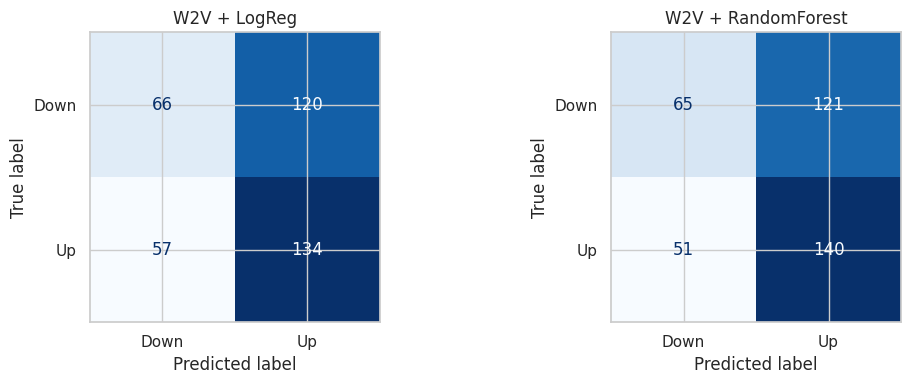

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, pred, title in zip(axes,
                            [pred_lr_w2v, pred_rf_w2v],
                            ['W2V + LogReg', 'W2V + RandomForest']):
    ConfusionMatrixDisplay.from_predictions(
        y_test, pred, display_labels=['Down', 'Up'],
        colorbar=False, ax=ax, cmap='Blues'
    )
    ax.set_title(title)
plt.tight_layout()
plt.show()

---
## Part B — TF-IDF Features (CPU-friendly)

TF-IDF is built on **stemmed** tokens (same preprocessing as before, consistent pipeline).  
The same vectorizer is reused for all classifiers — including Random Forest — to ensure a **fair comparison**.

> **Random Forest on sparse TF-IDF:** sklearn converts sparse → dense internally.  
> We cap `max_features=5000` to keep memory manageable while still being on the same representation as LR and SVM.


In [16]:
# FIX: use stemmed corpus (consistent with token preprocessing)
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.90,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(train_corpus_stemmed)
X_test_tfidf  = tfidf.transform(test_corpus_stemmed)

print('TF-IDF shapes — Train:', X_train_tfidf.shape, '| Test:', X_test_tfidf.shape)


TF-IDF shapes — Train: (1611, 20000) | Test: (377, 20000)


In [17]:
# --- Logistic Regression on TF-IDF ---
lr_tfidf = LogisticRegression(
    max_iter=2000,
    C=1.0,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
cv_lr_tfidf, cv_lr_tfidf_folds = time_series_cv_binary(
    'TF-IDF + LogReg', lr_tfidf, X_train_tfidf, y_train
)
cv_results_rows.append(cv_lr_tfidf)

lr_tfidf.fit(X_train_tfidf, y_train)
pred_lr_tfidf = lr_tfidf.predict(X_test_tfidf)
prob_lr_tfidf = lr_tfidf.predict_proba(X_test_tfidf)[:, 1]
metrics_lr_tfidf = evaluate(
    'TF-IDF + Logistic Regression', y_test, pred_lr_tfidf,
    y_score=prob_lr_tfidf, y_prob=prob_lr_tfidf
)

# --- Multinomial Naive Bayes on TF-IDF ---
nb_tfidf = MultinomialNB()
cv_nb_tfidf, cv_nb_tfidf_folds = time_series_cv_binary(
    'TF-IDF + MultinomialNB', nb_tfidf, X_train_tfidf, y_train
)
cv_results_rows.append(cv_nb_tfidf)

nb_tfidf.fit(X_train_tfidf, y_train)
pred_nb_tfidf = nb_tfidf.predict(X_test_tfidf)
prob_nb_tfidf = nb_tfidf.predict_proba(X_test_tfidf)[:, 1]
metrics_nb_tfidf = evaluate(
    'TF-IDF + MultinomialNB', y_test, pred_nb_tfidf,
    y_score=prob_nb_tfidf, y_prob=prob_nb_tfidf
)

# --- Linear SVM on TF-IDF ---
svm_tfidf = LinearSVC(
    class_weight='balanced',
    random_state=RANDOM_STATE,
    max_iter=4000
)
cv_svm_tfidf, cv_svm_tfidf_folds = time_series_cv_binary(
    'TF-IDF + LinearSVM', svm_tfidf, X_train_tfidf, y_train
)
cv_results_rows.append(cv_svm_tfidf)

svm_tfidf.fit(X_train_tfidf, y_train)
pred_svm_tfidf = svm_tfidf.predict(X_test_tfidf)
score_svm_tfidf = svm_tfidf.decision_function(X_test_tfidf)
metrics_svm_tfidf = evaluate(
    'TF-IDF + Linear SVM', y_test, pred_svm_tfidf,
    y_score=score_svm_tfidf, y_prob=None
)

print("\nUpdated CV ranking after TF-IDF models:")
display(pd.DataFrame(cv_results_rows).set_index("Model").round(4))



=== TF-IDF + Logistic Regression ===
  Accuracy          : 0.5252
  Balanced Accuracy : 0.5230
  Precision         : 0.5240
  Recall            : 0.6859
  F1                : 0.5941
  MCC               : 0.0487
  ROC-AUC           : 0.5341
  PR-AUC            : 0.5335
  Brier             : 0.2498
              precision    recall  f1-score   support

        Down       0.53      0.36      0.43       186
          Up       0.52      0.69      0.59       191

    accuracy                           0.53       377
   macro avg       0.53      0.52      0.51       377
weighted avg       0.53      0.53      0.51       377


=== TF-IDF + MultinomialNB ===
  Accuracy          : 0.5066
  Balanced Accuracy : 0.5000
  Precision         : 0.5066
  Recall            : 1.0000
  F1                : 0.6725
  MCC               : 0.0000
  ROC-AUC           : 0.5336
  PR-AUC            : 0.5437
  Brier             : 0.2764
              precision    recall  f1-score   support

        Down       0.00   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



=== TF-IDF + Linear SVM ===
  Accuracy          : 0.5411
  Balanced Accuracy : 0.5399
  Precision         : 0.5402
  Recall            : 0.6335
  F1                : 0.5831
  MCC               : 0.0812
  ROC-AUC           : 0.5310
  PR-AUC            : 0.5363
  Brier             : not defined
              precision    recall  f1-score   support

        Down       0.54      0.45      0.49       186
          Up       0.54      0.63      0.58       191

    accuracy                           0.54       377
   macro avg       0.54      0.54      0.54       377
weighted avg       0.54      0.54      0.54       377


Updated CV ranking after TF-IDF models:


,Accuracy,Balanced Accuracy,Precision,Recall,F1,MCC,ROC-AUC,PR-AUC,Brier,Fold,CV folds
Model,,,,,,,,,,,
W2V + LogReg,0.4754,0.4714,0.5213,0.5034,0.5069,-0.0599,0.4737,0.5431,0.2794,3.0,5
W2V + RandomForest,0.5254,0.5183,0.5671,0.5952,0.5785,0.0366,0.5027,0.5518,0.2548,3.0,5
TF-IDF + LogReg,0.5082,0.4946,0.5465,0.6243,0.5818,-0.0112,0.4952,0.5563,0.2503,3.0,5
TF-IDF + MultinomialNB,0.5410,0.4967,0.5486,0.9516,0.6934,-0.0078,0.4920,0.5567,0.2575,3.0,5
TF-IDF + LinearSVM,0.5090,0.4958,0.5468,0.6154,0.5783,-0.0082,0.4994,0.5599,NaN,3.0,5


In [18]:
# --- Random Forest on TF-IDF (exploratory only) ---
# Keep only the top chi2 features on the training set
from sklearn.feature_selection import SelectKBest, chi2

N_FEATURES_RF = 5000
selector_rf = SelectKBest(score_func=chi2, k=min(N_FEATURES_RF, X_train_tfidf.shape[1]))
X_train_tfidf_rf = selector_rf.fit_transform(X_train_tfidf, y_train)
X_test_tfidf_rf  = selector_rf.transform(X_test_tfidf)

rf_tfidf = RandomForestClassifier(
    n_estimators=200,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

cv_rf_tfidf, cv_rf_tfidf_folds = time_series_cv_binary(
    'TF-IDF + RandomForest', rf_tfidf, X_train_tfidf_rf, y_train
)
cv_results_rows.append(cv_rf_tfidf)

rf_tfidf.fit(X_train_tfidf_rf, y_train)
pred_rf_tfidf = rf_tfidf.predict(X_test_tfidf_rf)
prob_rf_tfidf = rf_tfidf.predict_proba(X_test_tfidf_rf)[:, 1]
metrics_rf_tfidf = evaluate(
    'TF-IDF + Random Forest (chi2 top 5k)', y_test, pred_rf_tfidf,
    y_score=prob_rf_tfidf, y_prob=prob_rf_tfidf
)

print("\nFinal CV ranking with all candidate models:")
display(pd.DataFrame(cv_results_rows).set_index("Model").round(4))



=== TF-IDF + Random Forest (chi2 top 5k) ===
  Accuracy          : 0.5172
  Balanced Accuracy : 0.5146
  Precision         : 0.5170
  Recall            : 0.7173
  F1                : 0.6009
  MCC               : 0.0318
  ROC-AUC           : 0.5178
  PR-AUC            : 0.5156
  Brier             : 0.2542
              precision    recall  f1-score   support

        Down       0.52      0.31      0.39       186
          Up       0.52      0.72      0.60       191

    accuracy                           0.52       377
   macro avg       0.52      0.51      0.50       377
weighted avg       0.52      0.52      0.50       377


Final CV ranking with all candidate models:


,Accuracy,Balanced Accuracy,Precision,Recall,F1,MCC,ROC-AUC,PR-AUC,Brier,Fold,CV folds
Model,,,,,,,,,,,
W2V + LogReg,0.4754,0.4714,0.5213,0.5034,0.5069,-0.0599,0.4737,0.5431,0.2794,3.0,5
W2V + RandomForest,0.5254,0.5183,0.5671,0.5952,0.5785,0.0366,0.5027,0.5518,0.2548,3.0,5
TF-IDF + LogReg,0.5082,0.4946,0.5465,0.6243,0.5818,-0.0112,0.4952,0.5563,0.2503,3.0,5
TF-IDF + MultinomialNB,0.5410,0.4967,0.5486,0.9516,0.6934,-0.0078,0.4920,0.5567,0.2575,3.0,5
TF-IDF + LinearSVM,0.5090,0.4958,0.5468,0.6154,0.5783,-0.0082,0.4994,0.5599,NaN,3.0,5
TF-IDF + RandomForest,0.6761,0.6521,0.6489,0.9062,0.7548,0.3600,0.7722,0.8061,0.2118,3.0,5


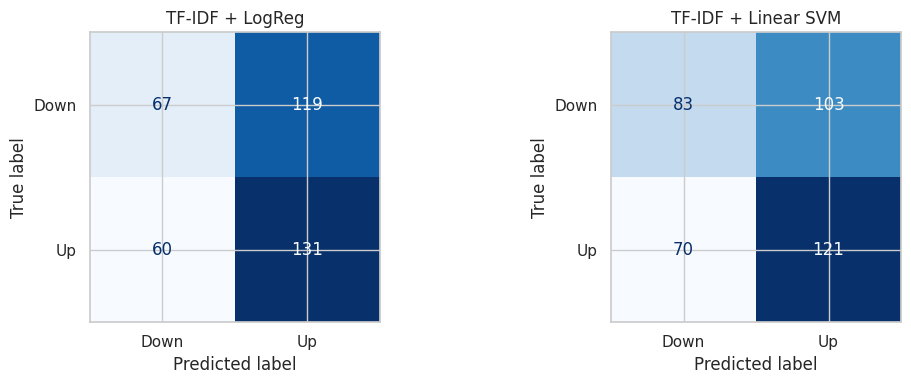

In [19]:
# Quick confusion matrices for the strongest CPU-friendly models
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, pred, title in zip(
    axes,
    [pred_lr_tfidf, pred_svm_tfidf],
    ['TF-IDF + LogReg', 'TF-IDF + Linear SVM']
):
    ConfusionMatrixDisplay.from_predictions(
        y_test, pred, display_labels=['Down', 'Up'],
        cmap='Blues', colorbar=False, ax=ax
    )
    ax.set_title(title)

plt.tight_layout()
plt.show()


---
## 6. Model Comparison

,Accuracy,Balanced Accuracy,Precision,Recall,F1,MCC,ROC-AUC,PR-AUC,Brier,Fold,CV folds,Test Accuracy,Test Balanced Accuracy,Test Precision,Test Recall,Test F1,Test MCC,Test ROC-AUC,Test PR-AUC,Selection_OK
Model,,,,,,,,,,,,,,,,,,,,
TF-IDF + RandomForest,0.6761,0.6521,0.6489,0.9062,0.7548,0.3600,0.7722,0.8061,0.2118,3.0,5.0,0.5172,0.5146,0.5170,0.7173,0.6009,0.0318,0.5178,0.5156,True
W2V + RandomForest,0.5254,0.5183,0.5671,0.5952,0.5785,0.0366,0.5027,0.5518,0.2548,3.0,5.0,0.5438,0.5412,0.5364,0.7330,0.6195,0.0893,0.5342,0.5139,True
Naive (majority),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.5066,0.5000,0.5066,1.0000,0.6725,0.0000,NaN,NaN,True
TF-IDF + MultinomialNB,0.5410,0.4967,0.5486,0.9516,0.6934,-0.0078,0.4920,0.5567,0.2575,3.0,5.0,0.5066,0.5000,0.5066,1.0000,0.6725,0.0000,0.5336,0.5437,False
TF-IDF + LinearSVM,0.5090,0.4958,0.5468,0.6154,0.5783,-0.0082,0.4994,0.5599,NaN,3.0,5.0,0.5411,0.5399,0.5402,0.6335,0.5831,0.0812,0.5310,0.5363,False
TF-IDF + LogReg,0.5082,0.4946,0.5465,0.6243,0.5818,-0.0112,0.4952,0.5563,0.2503,3.0,5.0,0.5252,0.5230,0.5240,0.6859,0.5941,0.0487,0.5341,0.5335,False
W2V + LogReg,0.4754,0.4714,0.5213,0.5034,0.5069,-0.0599,0.4737,0.5431,0.2794,3.0,5.0,0.5305,0.5282,0.5276,0.7016,0.6022,0.0602,0.5292,0.5244,False


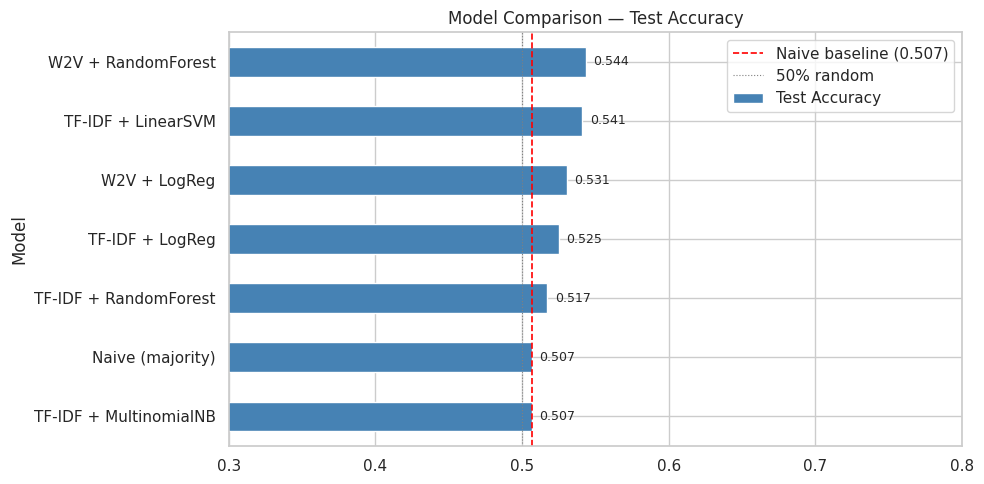

In [20]:
import pandas as pd

models_eval = {
    'Naive (majority)': {
        'pred': pred_dummy,
        'prob': None,
    },
    'W2V + LogReg': {
        'pred': pred_lr_w2v,
        'prob': prob_lr_w2v,
    },
    'W2V + RandomForest': {
        'pred': pred_rf_w2v,
        'prob': prob_rf_w2v,
    },
    'TF-IDF + LogReg': {
        'pred': pred_lr_tfidf,
        'prob': prob_lr_tfidf,
    },
    'TF-IDF + MultinomialNB': {
        'pred': pred_nb_tfidf,
        'prob': prob_nb_tfidf,
    },
    'TF-IDF + LinearSVM': {
        'pred': pred_svm_tfidf,
        'prob': score_svm_tfidf,
    },
    'TF-IDF + RandomForest': {
        'pred': pred_rf_tfidf,
        'prob': prob_rf_tfidf,
    },
}

test_rows = []
for name, d in models_eval.items():
    yp = d['pred']
    ypr = d['prob']

    row = {
        'Model'            : name,
        'Test Accuracy'    : accuracy_score(y_test, yp),
        'Test Balanced Accuracy': balanced_accuracy_score(y_test, yp),
        'Test Precision'   : precision_score(y_test, yp, zero_division=0),
        'Test Recall'      : recall_score(y_test, yp, zero_division=0),
        'Test F1'          : f1_score(y_test, yp, zero_division=0),
        'Test MCC'         : matthews_corrcoef(y_test, yp),
        'Test ROC-AUC'     : roc_auc_score(y_test, ypr) if ypr is not None else float('nan'),
        'Test PR-AUC'      : average_precision_score(y_test, ypr) if ypr is not None else float('nan'),
    }
    test_rows.append(row)

test_results_df = pd.DataFrame(test_rows).set_index('Model')
cv_results_df = pd.DataFrame(cv_results_rows).set_index('Model')

results_df = cv_results_df.join(test_results_df, how='outer')
results_df['Selection_OK'] = results_df['ROC-AUC'].isna() | (results_df['ROC-AUC'] >= 0.50)

# Selection is based on CV only, not on the final test set
results_df = results_df.sort_values(
    by=['Selection_OK', 'MCC', 'Balanced Accuracy', 'F1'],
    ascending=False
)

display(results_df.round(4))

# Plot test accuracy only for visualization
plot_series = results_df['Test Accuracy'].dropna().sort_values()
ax = plot_series.plot.barh(figsize=(10, 5), color='steelblue', edgecolor='white')
naive_acc = accuracy_score(y_test, pred_dummy)
ax.axvline(naive_acc, ls='--', color='red', lw=1.2, label=f'Naive baseline ({naive_acc:.3f})')
ax.axvline(0.5, ls=':', color='grey', lw=0.8, label='50% random')
ax.set_xlim(0.3, 0.8)

for p in ax.patches:
    ax.text(
        p.get_width() + 0.005,
        p.get_y() + p.get_height() / 2,
        f'{p.get_width():.3f}',
        va='center',
        fontsize=9
    )

plt.title('Model Comparison — Test Accuracy')
plt.legend()
plt.tight_layout()
plt.show()


In [21]:
# MODEL BEHAVIOR ANALYSIS


print("\n===== MODEL BEHAVIOR ANALYSIS =====")

y_pred     = pred_lr_tfidf
model      = lr_tfidf
model_name = "Logistic Regression (TF-IDF)"

print(f"\nAnalyzing model: {model_name}")

# 1. ERROR ANALYSIS
analysis_df = pd.DataFrame({
    "text": test_corpus_raw,     # human-readable raw text for display
    "true": y_test,
    "pred": y_pred
})

errors  = analysis_df[analysis_df["true"] != analysis_df["pred"]].copy()
correct = analysis_df[analysis_df["true"] == analysis_df["pred"]].copy()

print("\n--- Errors ---")
print("Number of errors:", len(errors))
display(errors.head(10))

print("\n--- Correct predictions ---")
display(correct.head(10))

# 2. TEXT LENGTH ANALYSIS
errors["length"]  = errors["text"].apply(len)
correct["length"] = correct["text"].apply(len)

print("\n--- Text length (errors) ---")
print(errors["length"].describe())
print("\n--- Text length (correct) ---")
print(correct["length"].describe())

# 3. PREDICTION DISTRIBUTION (BIAS)
print("\n--- Prediction distribution ---")
preds_series = pd.Series(y_pred)
print(preds_series.value_counts())
print(preds_series.value_counts(normalize=True))

# 4. MANUAL TEST CASES
# FIX: preprocess test sentences through the same pipeline (clean + stem) before vectorizing
print("\n--- Manual test cases ---")

def preprocess_for_tfidf(text):
    """Apply same cleaning + stemming as training data before TF-IDF transform."""
    text = re.sub(r'[^a-zA-Z]', ' ', text).lower()
    tokens = [stemmer.stem(w) for w in text.split() if w not in STOP_WORDS and len(w) > 1]
    return ' '.join(tokens)

test_sentences_raw = [
    "Stock market rises after strong earnings",
    "Global crisis causes markets to crash",
    "Uncertain outlook for investors",
    "Company reports mixed results",
    "Investors are optimistic about future growth",
    "Economic slowdown worries analysts"
]

# FIX: stem before vectorizing (same pipeline as training)
test_sentences_proc = [preprocess_for_tfidf(s) for s in test_sentences_raw]
X_manual     = tfidf.transform(test_sentences_proc)
preds_manual = model.predict(X_manual)

for text, pred in zip(test_sentences_raw, preds_manual):
    label = 'Up ↑' if pred == 1 else 'Down ↓'
    print(f"{text} → {label}")

# 5. SENSITIVITY TEST
print("\n--- Sensitivity test ---")
text1 = "Market rises after good news"
text2 = "Market falls after good news"

X_sens = tfidf.transform([preprocess_for_tfidf(text1), preprocess_for_tfidf(text2)])
preds_sens = model.predict(X_sens)

print(text1, "→", 'Up ↑' if preds_sens[0]==1 else 'Down ↓')
print(text2, "→", 'Up ↑' if preds_sens[1]==1 else 'Down ↓')



===== MODEL BEHAVIOR ANALYSIS =====

Analyzing model: Logistic Regression (TF-IDF)

--- Errors ---
Number of errors: 179


,text,true,pred
0,cases cancer result sheer bad luck rather unhe...,0,1
2,us oil falls barrel toyota gives away fuel cel...,1,0
5,muslim politician india offered charlie hebdo ...,0,1
6,world largest indoor farm japan times producti...,0,1
7,china banned burqa biggest muslim city us eu p...,0,1
9,saudi man sentenced years jail weekly public c...,1,0
10,saudi arabia publicly beheads woman mecca boko...,1,0
16,greece new finance minister yanis varoufakis v...,0,1
23,jordan carries air strikes iraq killing milita...,0,1
24,supreme court canada strikes ban doctor assist...,0,1



--- Correct predictions ---


,text,true,pred
1,moscow gt beijing high speed train reduce trip...,0,0
3,shots fired french magazine hq bibi netanyahus...,1,1
4,new charlie hebdo issue come next week hard su...,0,0
8,cameroon army kills boko haram fighters air fr...,0,0
11,good news tiger numbers india years iranian ne...,1,1
12,ebola killed third world gorillas chimpanzees ...,1,1
13,isis suffers heaviest defeat iraq single day s...,0,0
14,kurds invited anti isis conference london desp...,1,1
15,wikileaks demands answers google hands staff e...,0,0
17,key hepatitis patent rejected india clearing w...,1,1



--- Text length (errors) ---
count     179.000000
mean     2194.525140
std       290.074445
min      1480.000000
25%      1981.500000
50%      2187.000000
75%      2394.000000
max      2963.000000
Name: length, dtype: float64

--- Text length (correct) ---
count     198.000000
mean     2207.656566
std       255.552558
min      1575.000000
25%      2023.500000
50%      2197.000000
75%      2387.500000
max      2835.000000
Name: length, dtype: float64

--- Prediction distribution ---
1    250
0    127
Name: count, dtype: int64
1    0.66313
0    0.33687
Name: proportion, dtype: float64

--- Manual test cases ---
Stock market rises after strong earnings → Up ↑
Global crisis causes markets to crash → Down ↓
Uncertain outlook for investors → Up ↑
Company reports mixed results → Up ↑
Investors are optimistic about future growth → Down ↓
Economic slowdown worries analysts → Down ↓

--- Sensitivity test ---
Market rises after good news → Up ↑
Market falls after good news → Up ↑


In [22]:
# TOP POSITIVE / NEGATIVE FEATURES

feature_names = tfidf.get_feature_names_out()
coefs = lr_tfidf.coef_[0]

top_pos_idx = np.argsort(coefs)[-20:][::-1]
top_neg_idx = np.argsort(coefs)[:20]

top_pos_df = pd.DataFrame({
    "feature": feature_names[top_pos_idx],
    "coef": coefs[top_pos_idx]
})

top_neg_df = pd.DataFrame({
    "feature": feature_names[top_neg_idx],
    "coef": coefs[top_neg_idx]
})

print("Top positive features (predict Up tomorrow)")
display(top_pos_df)

print("Top negative features (predict Down tomorrow)")
display(top_neg_df)


Top positive features (predict Up tomorrow)


,feature,coef
0,australia,0.664448
1,abl,0.606540
2,al,0.599517
3,chemic,0.578525
4,kidnap,0.578021
5,libya,0.576062
6,author,0.574070
7,full,0.571768
8,enemi,0.556045
9,reveal,0.546764


Top negative features (predict Down tomorrow)


,feature,coef
0,follow,-0.728520
1,magnitud,-0.625930
2,face,-0.624189
3,mexico,-0.594436
4,crack,-0.575865
5,releas,-0.572730
6,bodi,-0.558102
7,seek,-0.554613
8,sentenc,-0.526741
9,radioact,-0.526415



===== MODEL ROBUSTNESS ANALYSIS =====
Model tested: Logistic Regression (TF-IDF)
Test samples : 377

--- Baseline ---
Accuracy: 0.5252
F1      : 0.5941

--- Robustness summary ---


,Test,Accuracy,F1,Agreement vs Baseline,Accuracy Drop,F1 Drop
1,truncate_50pct,0.5358,0.5995,0.7772,-0.0106,-0.0054
0,no_punctuation,0.5252,0.5941,1.0000,0.0000,0.0000
4,remove_market_words,0.5252,0.5923,0.9788,0.0000,0.0018
3,remove_20pct_words,0.5358,0.5921,0.8568,-0.0106,0.0020
2,truncate_30pct,0.5358,0.5763,0.6923,-0.0106,0.0178



--- Examples where prediction changes (truncate_50pct) ---
Changed predictions: 84


,original_text,perturbed_text,baseline_pred,perturbed_pred,true_label
0,world largest indoor farm japan time product o...,world largest indoor farm japan time product o...,1,0,0
1,china ban burqa biggest muslim citi us eu poli...,china ban burqa biggest muslim citi us eu poli...,1,0,0
2,saudi man sentenc year jail weekli public cane...,saudi man sentenc year jail weekli public cane...,0,1,1
3,kurd invit anti isi confer london despit lead ...,kurd invit anti isi confer london despit lead ...,1,0,1
4,boko haram appear surround citi million threat...,boko haram appear surround citi million threat...,0,1,0
5,jordan carri air strike iraq kill milit russia...,jordan carri air strike iraq kill milit russia...,1,0,0
6,isi burn rare book manuscript mosul satellit i...,isi burn rare book manuscript mosul satellit i...,1,0,0
7,thousand moscow chant russia without putin cha...,thousand moscow chant russia without putin cha...,1,0,0
8,anonym releas isi support twitter account name...,anonym releas isi support twitter account name...,0,1,0
9,tape drape across finish line nasa celebr win ...,tape drape across finish line nasa celebr win ...,1,0,0



--- Temporal robustness ---


/tmp/ipykernel_14724/2676595923.py:111: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  yearly_scores = test_eval_df.groupby("Year").apply(


,Year,Accuracy,F1,Support
0,2015,0.527778,0.604651,252.0
1,2016,0.520000,0.571429,125.0


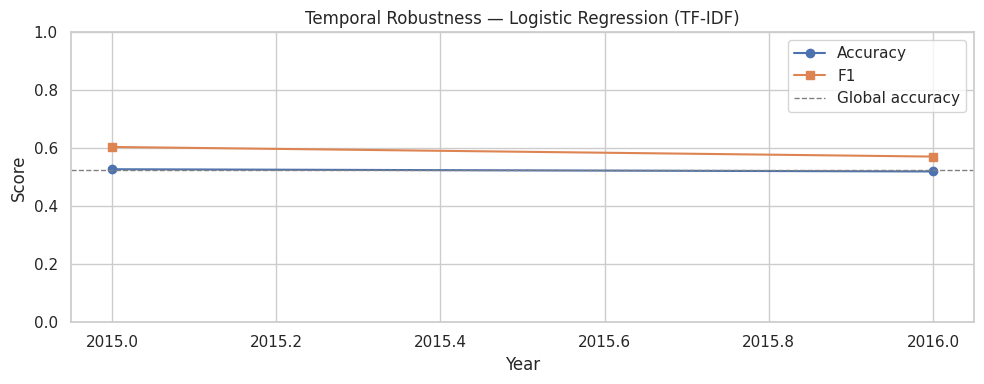

In [23]:
# MODEL ROBUSTNESS ANALYSIS (NLP)

import random
from sklearn.metrics import accuracy_score, f1_score

print("\n===== MODEL ROBUSTNESS ANALYSIS =====")

model      = lr_tfidf
model_name = "Logistic Regression (TF-IDF)"
# FIX: use stemmed corpus (what the vectorizer was trained on)
X_test_text = test_corpus_stemmed

print(f"Model tested: {model_name}")
print(f"Test samples : {len(X_test_text)}")

X_test_base = tfidf.transform(X_test_text)
base_pred   = model.predict(X_test_base)
base_acc    = accuracy_score(y_test, base_pred)
base_f1     = f1_score(y_test, base_pred)

print("\n--- Baseline ---")
print("Accuracy:", round(base_acc, 4))
print("F1      :", round(base_f1, 4))

# Perturbation functions
def remove_punctuation(text):
    return re.sub(r"[^\w\s]", " ", text)

def collapse_spaces(text):
    return re.sub(r"\s+", " ", text).strip()

def truncate_text(text, ratio=0.5):
    words = text.split()
    keep  = max(1, int(len(words) * ratio))
    return " ".join(words[:keep])

def remove_random_words(text, drop_ratio=0.2, seed=42):
    words = text.split()
    if len(words) <= 3:
        return text
    rng  = random.Random(seed)
    kept = [w for w in words if rng.random() > drop_ratio]
    return " ".join(kept) if kept else words[0]

def remove_market_words(text):
    market_words = {
        "market", "markets", "stock", "stocks", "share", "shares",
        "investor", "investors", "earning", "profit", "loss",
        "growth", "fall", "falls", "rise", "rises", "drop", "drops"
    }
    words = text.split()
    kept  = [w for w in words if w.lower() not in market_words]
    return " ".join(kept) if kept else text

robustness_tests = {
    "no_punctuation"    : [collapse_spaces(remove_punctuation(t)) for t in X_test_text],
    "truncate_50pct"    : [truncate_text(t, ratio=0.5) for t in X_test_text],
    "truncate_30pct"    : [truncate_text(t, ratio=0.3) for t in X_test_text],
    "remove_20pct_words": [remove_random_words(t, drop_ratio=0.2, seed=42) for t in X_test_text],
    "remove_market_words": [remove_market_words(t) for t in X_test_text],
}

robustness_results = []
for test_name, perturbed_texts in robustness_tests.items():
    X_perturbed    = tfidf.transform(perturbed_texts)
    pred_perturbed = model.predict(X_perturbed)
    acc            = accuracy_score(y_test, pred_perturbed)
    f1             = f1_score(y_test, pred_perturbed)
    agreement      = (pred_perturbed == base_pred).mean()
    robustness_results.append({
        "Test"                 : test_name,
        "Accuracy"             : round(acc, 4),
        "F1"                   : round(f1, 4),
        "Agreement vs Baseline": round(agreement, 4),
        "Accuracy Drop"        : round(base_acc - acc, 4),
        "F1 Drop"              : round(base_f1 - f1, 4),
    })

robustness_df = pd.DataFrame(robustness_results).sort_values("F1", ascending=False)
print("\n--- Robustness summary ---")
display(robustness_df)

# Exemples de changements
print("\n--- Examples where prediction changes (truncate_50pct) ---")
example_texts = robustness_tests["truncate_50pct"]
example_preds = model.predict(tfidf.transform(example_texts))
changed_idx   = np.where(example_preds != base_pred)[0]

print(f"Changed predictions: {len(changed_idx)}")
if len(changed_idx) > 0:
    display(pd.DataFrame({
        "original_text" : [X_test_text[i] for i in changed_idx[:10]],
        "perturbed_text": [example_texts[i] for i in changed_idx[:10]],
        "baseline_pred" : [base_pred[i] for i in changed_idx[:10]],
        "perturbed_pred": [example_preds[i] for i in changed_idx[:10]],
        "true_label"    : [y_test[i] for i in changed_idx[:10]],
    }))

# Robustesse temporelle
print("\n--- Temporal robustness ---")
test_dates = df_news.loc[test_mask, "Date"].reset_index(drop=True)
test_eval_df = pd.DataFrame({
    "Date": pd.to_datetime(test_dates),
    "true": y_test,
    "pred": base_pred
})
test_eval_df["Year"] = test_eval_df["Date"].dt.year

yearly_scores = test_eval_df.groupby("Year").apply(
    lambda g: pd.Series({
        "Accuracy": accuracy_score(g["true"], g["pred"]),
        "F1": f1_score(g["true"], g["pred"]),
        "Support": len(g)
    })
).reset_index()

display(yearly_scores)

plt.figure(figsize=(10, 4))
plt.plot(yearly_scores["Year"], yearly_scores["Accuracy"], marker='o', label='Accuracy')
plt.plot(yearly_scores["Year"], yearly_scores["F1"], marker='s', label='F1')
plt.axhline(base_acc, color='grey', ls='--', lw=1, label='Global accuracy')
plt.title(f'Temporal Robustness — {model_name}')
plt.xlabel('Year')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()


In [24]:
selection_df = results_df.drop(index='Naive (majority)', errors='ignore').copy()

selection_df_valid = selection_df[
    selection_df['Selection_OK']
].copy()

if selection_df_valid.empty:
    selection_df_valid = selection_df.copy()

best_model_name = selection_df_valid.index[0]

print('Model ranking uses CV metrics only: Selection_OK -> MCC -> Balanced Accuracy -> F1')
print(f'Best non-naive model under this rule: {best_model_name}')
display(selection_df_valid.loc[[best_model_name]].round(4))


Model ranking uses CV metrics only: Selection_OK -> MCC -> Balanced Accuracy -> F1
Best non-naive model under this rule: TF-IDF + RandomForest


,Accuracy,Balanced Accuracy,Precision,Recall,F1,MCC,ROC-AUC,PR-AUC,Brier,Fold,CV folds,Test Accuracy,Test Balanced Accuracy,Test Precision,Test Recall,Test F1,Test MCC,Test ROC-AUC,Test PR-AUC,Selection_OK
Model,,,,,,,,,,,,,,,,,,,,
TF-IDF + RandomForest,0.6761,0.6521,0.6489,0.9062,0.7548,0.36,0.7722,0.8061,0.2118,3.0,5.0,0.5172,0.5146,0.517,0.7173,0.6009,0.0318,0.5178,0.5156,True


---
## 7. Backtest — Simple Long-Only Strategy

**Rule:** if the model predicts **Up → go long** the DJIA the *next* day; otherwise stay in cash.

**Important note:** this is an **exploratory backtest**, not a production-grade trading evaluation.
The same 2015–2016 holdout period is used both for model comparison and for the backtest,
so any apparent edge must be interpreted cautiously.

**Key fixes vs naive implementation:**
- **Signal shifted by 1 day** (`shift(1)`) — we only know today's news *after* market close, so we trade tomorrow
- **Return = Close-to-Close** (overnight P&L, not intraday)
- **Sharpe ratio** and **max drawdown** reported alongside total return
- **No transaction costs** or slippage modelled

> ⚠️ Because the classification scores are close to random, the backtest should be treated as a sanity check, not proof of exploitable alpha.


Backtest model selected from time-aware CV: TF-IDF + RandomForest


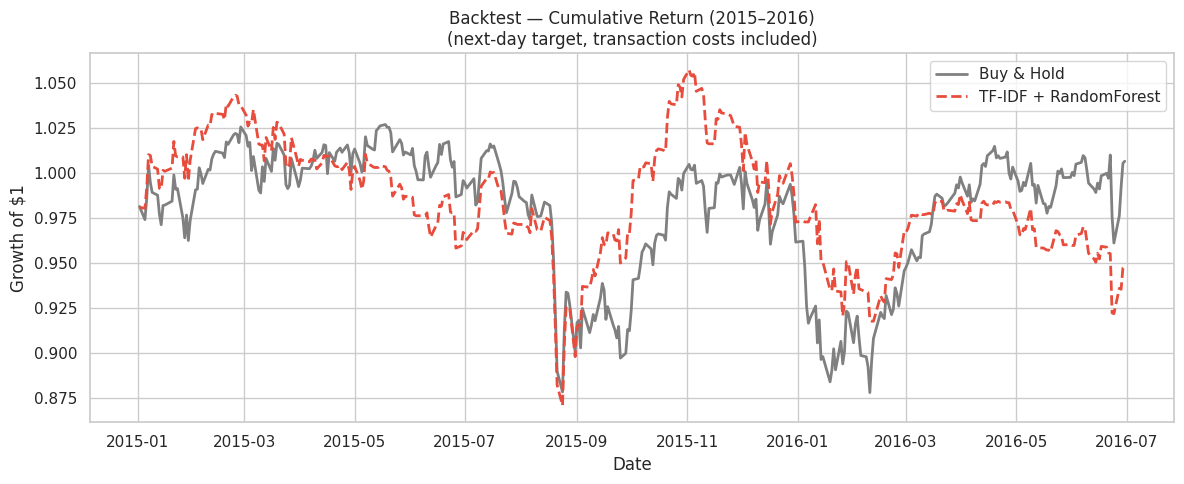


Metric                           Buy & Hold     Strategy
--------------------------------------------------------
Total return                         0.65%      -5.15%
Sharpe ratio (ann.)                    0.11        -0.19
Max Drawdown                       -14.48%     -16.50%
Days invested                           N/A          265
Turnover (daily avg)                    N/A      43.77%

Interpretation: model selection was done on training CV, then the backtest was shown on the final future holdout.


In [25]:
# Predictions dictionary
best_pred_dict = {
    'W2V + LogReg': pred_lr_w2v,
    'W2V + RandomForest': pred_rf_w2v,
    'TF-IDF + LogReg': pred_lr_tfidf,
    'TF-IDF + MultinomialNB': pred_nb_tfidf,
    'TF-IDF + LinearSVM': pred_svm_tfidf,
    'TF-IDF + RandomForest': pred_rf_tfidf,
}

selection_df = results_df.drop(index='Naive (majority)', errors='ignore').copy()
selection_df_valid = selection_df[selection_df['Selection_OK']].copy()
if selection_df_valid.empty:
    selection_df_valid = selection_df.copy()

best_pred_name = selection_df_valid.index[0]
best_pred = best_pred_dict[best_pred_name]

print(f"Backtest model selected from time-aware CV: {best_pred_name}")

# Build backtest dataframe on the final holdout only
bt = df_news.loc[test_mask, ['Date', 'Return_tomorrow']].copy().reset_index(drop=True)
bt['signal'] = best_pred.astype(int)

# Long-only strategy:
# signal = 1 -> invest for next day's close-to-close return
# signal = 0 -> stay in cash
bt['gross_strategy_return'] = bt['Return_tomorrow'] * bt['signal']

# Transaction costs: 5 bps when the position changes
cost_bps = 0.0005
bt['position_change'] = bt['signal'].diff().abs().fillna(bt['signal'])
bt['transaction_cost'] = bt['position_change'] * cost_bps

bt['strategy_return'] = bt['gross_strategy_return'] - bt['transaction_cost']
bt['buy_hold_return'] = bt['Return_tomorrow']

bt['cum_bnh'] = (1 + bt['buy_hold_return']).cumprod()
bt['cum_strategy'] = (1 + bt['strategy_return']).cumprod()

TRADING_DAYS = 252

def sharpe_ratio(returns, rf=0.0):
    excess = returns - rf / TRADING_DAYS
    return np.sqrt(TRADING_DAYS) * excess.mean() / (excess.std() + 1e-9)

def max_drawdown(cum_returns):
    peak = cum_returns.cummax()
    dd = (cum_returns - peak) / peak
    return dd.min()

sharpe_bnh = sharpe_ratio(bt['buy_hold_return'])
sharpe_strategy = sharpe_ratio(bt['strategy_return'])
mdd_bnh = max_drawdown(bt['cum_bnh'])
mdd_strategy = max_drawdown(bt['cum_strategy'])

days_invested = bt['signal'].sum()
turnover = bt['position_change'].sum() / len(bt)

plt.figure(figsize=(12, 5))
plt.plot(bt['Date'], bt['cum_bnh'], label='Buy & Hold', lw=2, color='grey')
plt.plot(bt['Date'], bt['cum_strategy'], label=best_pred_name, lw=2, color='#e74c3c', ls='--')
plt.title("Backtest — Cumulative Return (2015–2016)\n(next-day target, transaction costs included)")
plt.xlabel('Date')
plt.ylabel('Growth of $1')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\n{'Metric':<30} {'Buy & Hold':>12} {'Strategy':>12}")
print('-' * 56)
print(f"{'Total return':<30} {bt['cum_bnh'].iloc[-1] - 1:>11.2%} {bt['cum_strategy'].iloc[-1] - 1:>11.2%}")
print(f"{'Sharpe ratio (ann.)':<30} {sharpe_bnh:>12.2f} {sharpe_strategy:>12.2f}")
print(f"{'Max Drawdown':<30} {mdd_bnh:>11.2%} {mdd_strategy:>11.2%}")
print(f"{'Days invested':<30} {'N/A':>12} {days_invested:>12}")
print(f"{'Turnover (daily avg)':<30} {'N/A':>12} {turnover:>11.2%}")
print()
print("Interpretation: model selection was done on training CV, then the backtest was shown on the final future holdout.")


---
## 8. Summary

| Step | Detail |
|---|---|
| **Data** | 25 Reddit headlines/day + market close data |
| **Target** | **Next-day** close-to-close direction (`Target_tomorrow`) |
| **NaN filling** | Empty string `""` (not column mode) |
| **Preprocessing** | Regex → lowercase → stopwords removal → stemming for TF-IDF |
| **Word2Vec tokens** | Cleaned tokens without stemming — preserves more semantic context |
| **TF-IDF tokens** | Stemmed — compact vocabulary |
| **Word2Vec** | Trained on train corpus only; `workers=1` for reproducibility |
| **TF-IDF** | Unigrams + bigrams; same vectorizer for all linear classifiers |
| **Classifiers** | Logistic Regression, MultinomialNB, Random Forest, Linear SVM |
| **Naïve baseline** | Majority class — reference floor |
| **Metrics** | Accuracy, Balanced Accuracy, Precision, Recall, F1, MCC, ROC-AUC, PR-AUC, Brier |
| **Model selection** | Prefer **Selection_OK (ROC-AUC >= 0.50)** then **MCC**, **Balanced Accuracy**, **F1** |
| **Backtest** | Exploratory long-only strategy on **next-day returns**, with transaction costs |

**Key corrections applied:**
- Target aligned with the backtest horizon using **next-day** returns
- Added **Multinomial Naive Bayes** as a standard NLP baseline
- Expanded evaluation with **PR-AUC** and **Brier score**
- Added **top positive / negative TF-IDF features** for interpretability
- Fixed robustness table bug where `perturbed` column was overwritten
- TF-IDF Random Forest still uses **chi²-based feature selection** instead of arbitrary column slicing
- Tightened ranking logic to avoid selecting models with **ROC-AUC < 0.50** when alternatives exist
- Backtest now includes **transaction costs** and explicit next-day return alignment

**Important interpretation:**
- Classification performance may still remain close to random overall.
- The notebook is therefore best viewed as a **well-structured exploratory NLP/finance pipeline** rather than evidence of a strong predictive edge.
- A more defensible next step would be a **walk-forward evaluation** or a separate validation period for model selection.
